In [1]:
import numpy as np
from functools import reduce
from ripser import ripser
from collections import Counter
import matplotlib.pyplot as plt
from persim import plot_diagrams
import pandas as pd
from plottable import Table
import math


from math import floor, ceil


In [2]:
#cycleList = [17, 5] # <--- Change cycles to (x)

def cycleDist(i,j,n): return min((i-j)%n,(j-i)%n) # Distance between points i and j in a cycle of size n
def cycleMatrix(n): return np.array([[cycleDist(i,j,n) for i in range(n)] for j in range(n)]) # Distance matrix for the cycle graph of size n

def product_sum(M, N): # computes the distance matrix of the product of two matrix spaces using the sum metric
	return np.block([[M + n for n in column] for column in N])

def maxProduct(M, N): # computes the distance matrix using the max matric rather than the sum metric
	return np.block([[np.maximum(M,n)  for n in column] for column in N])

def prism(M): return np.block([[M,M+1],[M+1,M]]) # Applies the prism operator we defined to a distance matrix (in other words, take the product of that metric space with the interval matric space using the sum metric

usePrism = False # <------------ CHANGE FOR PRISM OPERATION	
PrismCount = 0 # <------------ # of prism operations 

useMax = False # <------------ CHANGE FOR MAX/SUM 



In [3]:
from tqdm.notebook import tqdm

cyclemin = int(input('What minimum cycle size would you like to take the persistent homology in? '))  
cyclemax = int(input('What maximum cycle size would you like to take the persistent homology in? '))
dimMin = int(input('What minimum dimension would you like to take the persistent homology in? '))   
dimMax = int(input('What maximum dimension would you like to take the persistent homology in? '))

grid_size = cyclemax - cyclemin + 1
MGrid = [[0] * (grid_size) for _ in range(grid_size)]

for n in tqdm(range(cyclemin, cyclemax + 1), desc="Computing Homology Grid"):
    row_idx = n - cyclemin
    for m in range(n, cyclemax + 1):
        col_idx = m - cyclemin
        M = product_sum(cycleMatrix(n),cycleMatrix(m))
        result = ripser(M, distance_matrix=True, maxdim = dimMax)
        dgms_data = result['dgms']

        # AI Code ---------
        clean_cell_data = {}
        
        for dim in range(dimMin, dimMax + 1):
            if dim < len(dgms_data) and len(dgms_data[dim]) > 0:
                intervals = [
                    (int(round(b, 2)) if round(b, 2).is_integer() else round(b, 2),
                    int(round(d, 2)) if round(d, 2).is_integer() else round(d, 2)) 
                    for b, d in dgms_data[dim]]
                
                clean_cell_data[dim] = dict(Counter(intervals))
            else:
                clean_cell_data[dim] = {} 
        # ----------
        MGrid[row_idx][col_idx] = clean_cell_data
        MGrid[col_idx][row_idx] = clean_cell_data


#MGrid
            

Computing Homology Grid:   0%|          | 0/3 [00:00<?, ?it/s]

3 3 1 1 0 0
{(1, 2): 0, (2, 2): 0} 

3 5 0 1 1 0
{(1, 2): 0, (2, 2): 0, (2, 3): 2} 

3 5 0 1 1 0
{(1, 2): 0, (2, 2): 0, (2, 3): 2} 

5 5 0 0 1 1
{(1, 2): 0, (2, 3): 9} 



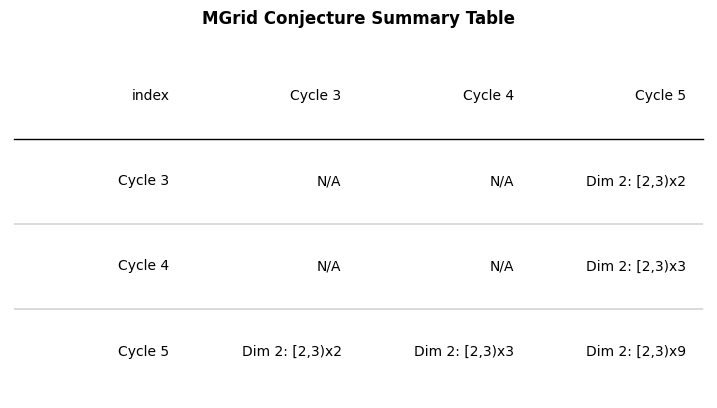

In [4]:
# AI Code for table here --------------------------------------------->

# 1. Setup labels
labels = [f"Cycle {i}" for i in range(cyclemin, cyclemax + 1)]

# 2. Inline version of compute() that returns a dict instead of printing
def compute_dict(n, m):
    if m < n: # WLOG
        swap = m 
        m = n
        n = swap

    a = math.ceil(n/3)
    b = math.ceil(m/3)
    #print(n, m, a, b)

    if n % 3 == 0:
        p = (n/3) - 1;  n_mod3 = 1
    elif n % 3 == 1:
        p = 0;           n_mod3 = 0
    else:
        p = 0;           n_mod3 = 1

    if m % 3 == 0:
        q = (m/3) - 1;  m_mod3 = 1
    elif m % 3 == 1:
        q = 0;           m_mod3 = 0
    else:
        q = 0;           m_mod3 = 1

    n3m1 = 0 if (n==3 and m%3==1) else 1
    if (n % 3 != 1) and (m % 3 != 1): # This is the old conjecture (Carlsson)/JMU
        md3 = 1 if (m%3==0) else 0
        nd3 = 1 if (n%3==0) else 0
        mne3 = 1 if (m!=3) else 0
        nne3 = 1 if (n!=3) else 0     
        
        bars = {}
        def add_bar(key, val):
            bars[key] = bars.get(key, 0) + val
                                                        
        # add_bar((m//3, m//3+1), md3*(2*(n-1)*(b-1)))  Previous Carlsson results left unedited here
        # add_bar((n//3, n//3+1), nd3*(2*(m-1)*(a-1)))  <-------------------------------------------

        add_bar((m//3, m//3+1), md3*(2*(n-1)*(b-1)-3*(b-1)*(a-1))-(md3*nd3)*(b-1))   
        add_bar((n//3, n//3+1), nd3*(2*(m-1)*(a-1)-3*(a-1)*(b-1))-(md3*nd3)*(a-1))
        add_bar((2, a+1), nne3) # God rid of incorrect 2 multiplicity
        add_bar((b, b+1), mne3*(n-1)) 
        add_bar((a, a+1), nne3*(m-1))

        print(n, m, md3, nd3, mne3, nne3)
        print(bars, '\n')
    
    else: # This is the new Claudio/JMU conjeture
        if a < b:

            if a <= 2:
                bars = {(a, a+1): int((m*n_mod3 + p*m)*n3m1), (b, b+1): int((n-1)*m_mod3 + q*n)}
            else:
                if (n%3) != 1:
                    bars = {(2, a+1): 1, (a, a+1): int(m*n_mod3 + p*m - 1), (b, b+1): int((n-1)*m_mod3 + q*n)}
                else:
                    bars = {(2, a): 1, (a, a+1): int(m*n_mod3 + p*m), (b, b+1): int((n-1)*m_mod3 + q*n)}
        else:
            if a <= 2:
                bars = {(a, a+1): int(n_mod3*m_mod3 + (m-1)*n_mod3 + (n-1)*m_mod3 + p*m + q*n)}
            else:
                bars = {(2, a): 1, (a, a+1): int(n_mod3*m_mod3 + (m-1)*n_mod3 + (n-1)*m_mod3 + p*m + q*n)}

    return {2: {k: v for k, v in bars.items() if v > 0}}

def epsilon(t):
    if t % 3 == 1 or t == 3:
        return 0
    elif t % 3 == 2:
        return 1
    elif t % 3 == 0 and t>3:
        return t//3

def delta(t):
    if epsilon(t) == 0:
        return 0
    elif epsilon(t) > 0:
        return 1

def M(t, s):
    return s*epsilon(t)-delta(t)

def compute_dict_simplified(n, m):
    a = math.ceil(n/3)
    b = math.ceil(m/3)

    bars = {(2, a+delta(n)): 1, (a, a+1): M(n, m), (b,b+1): M(m, n)}

    return {2: {k: v for k, v in bars.items() if v > 0}}

# 3. Rebuild MGrid_conjecture as proper dicts
grid_size = cyclemax - cyclemin + 1
MGrid_conjecture_dict = [[None] * grid_size for _ in range(grid_size)]
for n in range(cyclemin, cyclemax + 1):
    for m in range(cyclemin, cyclemax + 1):
        ni, mi = n - cyclemin, m - cyclemin
        lo, hi = (n, m) if n <= m else (m, n)
        MGrid_conjecture_dict[ni][mi] = compute_dict(lo, hi)
        # else leave as None (conjecture doesn't apply)

# 4. Convert to simple text lines
simple_grid = []
for row in MGrid_conjecture_dict:
    simple_row = []
    for cell_data in row:
        if cell_data is None or not any(cell_data.values()):
            simple_row.append("N/A")
            continue

        lines = []
        for dim, bars in cell_data.items():
            if bars:
                bar_strs = [f"[{b},{d})x{m}" for (b, d), m in bars.items()]
                lines.append(f"Dim {dim}: " + " | ".join(bar_strs))

        simple_row.append("\n".join(lines))
    simple_grid.append(simple_row)

# 5. Put into a Pandas DataFrame and plot
df = pd.DataFrame(simple_grid, index=labels, columns=labels)

fig, ax = plt.subplots(figsize=(3 * grid_size, 1.5 * grid_size))
tab = Table(df, ax=ax)
plt.title("MGrid Conjecture Summary Table", weight='bold', pad=20)
plt.show()

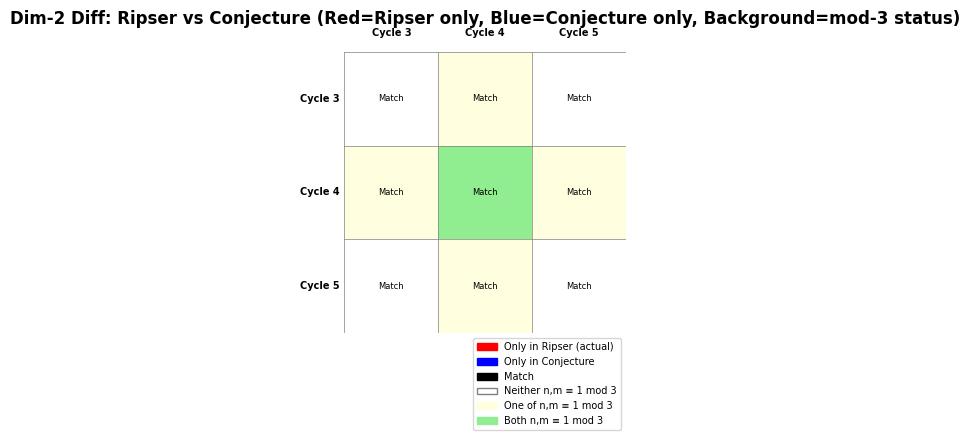

In [5]:
# AI Code for DIFF table --------------------------------------------->
import matplotlib.patches as mpatches

# 1. Labels already defined above

# 2. Build diff grid
diff_grid = []
for row_idx in range(grid_size):
    diff_row = []
    for col_idx in range(grid_size):
        ripser_cell = MGrid[row_idx][col_idx]
        conj_cell   = MGrid_conjecture_dict[row_idx][col_idx]

        # Extract dim-2 bars from Ripser
        ripser_bars = {}
        if ripser_cell and ripser_cell != 0:
            ripser_bars = ripser_cell.get(2, {})

        # Extract dim-2 bars from conjecture
        conj_bars = {}
        if conj_cell and conj_cell != 0:
            conj_bars = conj_cell.get(2, {})

        # Find bars unique to each side
        all_keys = set(ripser_bars.keys()) | set(conj_bars.keys())
        only_ripser = {}  # red
        only_conj   = {}  # blue

        for k in all_keys:
            r_mult = ripser_bars.get(k, 0)
            c_mult = conj_bars.get(k, 0)
            if r_mult != c_mult:
                if r_mult > 0:
                    only_ripser[k] = r_mult
                if c_mult > 0:
                    only_conj[k] = c_mult

        diff_row.append((only_ripser, only_conj))
    diff_grid.append(diff_row)

# 3. Render table manually with colored text
fig, ax = plt.subplots(figsize=(3 * grid_size, 1.5 * grid_size))
ax.set_xlim(0, grid_size)
ax.set_ylim(0, grid_size)
ax.set_aspect('equal')
ax.axis('off')

col_w = 1.0
row_h = 1.0

# Fill cell backgrounds based on mod-3 condition
for row_idx in range(grid_size):
    n = row_idx + cyclemin
    for col_idx in range(grid_size):
        m = col_idx + cyclemin

        n_is_1mod3 = (n % 3 == 1)
        m_is_1mod3 = (m % 3 == 1)

        if n_is_1mod3 and m_is_1mod3:
            bg_color = 'lightgreen'
        elif n_is_1mod3 or m_is_1mod3:
            bg_color = 'lightyellow'
        else:
            bg_color = 'white'

        rect = mpatches.Rectangle(
            (col_idx * col_w, (grid_size - row_idx - 1) * row_h),
            col_w, row_h,
            facecolor=bg_color, edgecolor='none', zorder=0
        )
        ax.add_patch(rect)

# Draw grid lines
for i in range(grid_size + 1):
    ax.axhline(i, color='gray', linewidth=0.5, zorder=1)
    ax.axvline(i, color='gray', linewidth=0.5, zorder=1)

# Column headers (top)
for col_idx, label in enumerate(labels):
    ax.text((col_idx + 0.5) * col_w, grid_size + 0.15, label,
            ha='center', va='bottom', fontsize=7, fontweight='bold')

# Row headers (left)
for row_idx, label in enumerate(labels):
    ax.text(-0.05, (grid_size - row_idx - 0.5) * row_h, label,
            ha='right', va='center', fontsize=7, fontweight='bold')

# Fill cells with text
for row_idx in range(grid_size):
    for col_idx in range(grid_size):
        only_ripser, only_conj = diff_grid[row_idx][col_idx]

        lines = []  # list of (text, color)

        for (b, d), mult in sorted(only_ripser.items()):
            lines.append((f"[{b},{d})x{mult}", 'red'))
        for (b, d), mult in sorted(only_conj.items()):
            lines.append((f"[{b},{d})x{mult}", 'blue'))

        if not lines:
            lines = [("Match", 'black')]

        n_lines = len(lines)
        cell_cx = (col_idx + 0.5) * col_w
        cell_cy = (grid_size - row_idx - 0.5) * row_h
        line_spacing = 0.18
        start_y = cell_cy + (n_lines - 1) * line_spacing / 2

        for li, (txt, color) in enumerate(lines):
            ax.text(cell_cx, start_y - li * line_spacing, txt,
                    ha='center', va='center', fontsize=6, color=color, zorder=2)

# Legend
red_patch    = mpatches.Patch(color='red',         label='Only in Ripser (actual)')
blue_patch   = mpatches.Patch(color='blue',        label='Only in Conjecture')
match_patch  = mpatches.Patch(color='black',       label='Match')
white_patch  = mpatches.Patch(facecolor='white',   edgecolor='gray', label='Neither n,m ≡ 1 mod 3')
yellow_patch = mpatches.Patch(color='lightyellow', label='One of n,m ≡ 1 mod 3')
green_patch  = mpatches.Patch(color='lightgreen',  label='Both n,m ≡ 1 mod 3')
ax.legend(handles=[red_patch, blue_patch, match_patch, white_patch, yellow_patch, green_patch],
          loc='upper right', bbox_to_anchor=(1.0, 0.0), fontsize=7)

plt.title("Dim-2 Diff: Ripser vs Conjecture (Red=Ripser only, Blue=Conjecture only, Background=mod-3 status)",
          weight='bold', pad=20)
plt.tight_layout()
plt.show()